# EMBED Risk Inference Visualization

This notebook loads the `embed_balanced_split_no_alignment_uniform_orientation` checkpoint from `output_models/risk_prediction_no_alignment_uniform_orientation`, finds a patient's valid longitudinal image pairs in the selected split, runs the no-alignment risk model, and shows the corresponding 1-5 year risk scores.

This follows the repository's actual test-time logic: inference is done per adjacent longitudinal pair within each `(patient, laterality, view)` track. A patient does not need to have all four standard views available on the same date.

The notebook reports:

- one 1-5 year risk vector for each valid longitudinal pair selected for the patient,
- a patient-level summary obtained by averaging the available pair-level predictions,
- the ground-truth outcome reconstructed from the CSV using the same target logic as the training/test dataset.

The last output unit of the model corresponds to the non-cancer / censoring bucket. For readability, the tables below focus on years 1-5.

In [12]:
import os
import re
import sys
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image
from IPython.display import display

PROJECT_ROOT = Path('/mnt/cv_data/users/mengxu/Longitudinal_Mammogram_Risk_Prediction')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.models.model_combined_alignment_risk import RiskModelNoAlignment

CSV_FILE = PROJECT_ROOT / 'output_csv' / 'EMBED_combined_cases_with_followup_with_split.csv'
DATA_ROOT = Path('/mnt/cv_data/users/mengxu/EMBED_Dataset_Split_Uniform_Orientation')
MODEL_PATH = PROJECT_ROOT / 'output_models' / 'risk_prediction_no_alignment_uniform_orientation' / 'early_stopping_risk_prediction_id-embed_balanced_split_no_alignment_uniform_orientation.pth'
STANDARD_VIEWS = [('L', 'CC'), ('L', 'MLO'), ('R', 'CC'), ('R', 'MLO')]
FILENAME_PATTERN = re.compile(r'^(\d+)_([A-Z]+)_([A-Z0-9]+)_(\d{4}-\d{2}-\d{2})_([A-Za-z0-9]+)_(pos_cancer|pos_nocancer|neg_nocancer)\.png$')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Using device: {DEVICE}')
print(f'Model path: {MODEL_PATH}')
print(f'CSV file: {CSV_FILE}')
print(f'Data root: {DATA_ROOT}')

Using device: cuda
Model path: /mnt/cv_data/users/mengxu/Longitudinal_Mammogram_Risk_Prediction/output_models/risk_prediction_no_alignment_uniform_orientation/early_stopping_risk_prediction_id-embed_balanced_split_no_alignment_uniform_orientation.pth
CSV file: /mnt/cv_data/users/mengxu/Longitudinal_Mammogram_Risk_Prediction/output_csv/EMBED_combined_cases_with_followup_with_split.csv
Data root: /mnt/cv_data/users/mengxu/EMBED_Dataset_Split_Uniform_Orientation


## Patient Selection

Set `PATIENT_ID` to the patient you want to inspect. The notebook will find all valid adjacent longitudinal pairs for that patient in the selected split.

If you set `STUDY_DATE`, the notebook keeps only pairs whose current image date matches that date. If you leave `STUDY_DATE = None`, it uses the latest available current exam date for that patient.

In [13]:
PATIENT_ID = '11910217'
SPLIT = 'test'
STUDY_DATE = '2014-10-23'
NUM_YEARS = 5

## Helper Functions

The helpers below mirror the repository logic:

- PNG loading and intensity normalization match `src/dataloaders/risk_prediction/dataset_embed.py`.
- Ground-truth reconstruction uses the same `Time_to_Cancer_Years` / `years_last_followup` logic that the dataset class uses to build the training target.

In [14]:
def imgunit16(img: np.ndarray) -> np.ndarray:
    img = img.astype(np.float32)
    img_min = img.min()
    img_max = img.max()
    if img_max == img_min:
        return np.zeros_like(img, dtype=np.float32)
    return (img - img_min) / (img_max - img_min) * 65535.0


def load_metadata(csv_file: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_file, low_memory=False)
    df['patient_id'] = df['patient_id'].astype(str).str.strip()
    df['ImageLateralityFinal'] = df['ImageLateralityFinal'].astype(str).str.strip()
    df['view'] = df['view'].astype(str).str.strip()
    df['study_date_anon'] = pd.to_datetime(df['study_date_anon'])
    return df


def build_image_index(split_dir: Path) -> pd.DataFrame:
    records = []
    for file_path in sorted(split_dir.glob('*.png')):
        match = FILENAME_PATTERN.match(file_path.name)
        if match is None:
            continue

        patient_id, laterality, view, study_date, last4, status_tag = match.groups()
        records.append(
            {
                'patient_id': patient_id,
                'laterality': laterality,
                'view': view,
                'study_date': pd.Timestamp(study_date),
                'last4': last4,
                'status_tag': status_tag,
                'filename': file_path.name,
                'path': file_path,
                'view_code': f'{laterality}{view}',
            }
        )

    if not records:
        raise FileNotFoundError(f'No PNG files were found in {split_dir}')

    return pd.DataFrame(records).sort_values(
        ['patient_id', 'study_date', 'laterality', 'view', 'filename']
    ).reset_index(drop=True)


def build_longitudinal_pair_index(image_df: pd.DataFrame, n_years: int = 5) -> pd.DataFrame:
    pair_rows = []
    grouped = image_df.groupby(['patient_id', 'laterality', 'view'], sort=False)

    for (patient_id, laterality, view), group_df in grouped:
        group_df = group_df.sort_values(['study_date', 'filename']).reset_index(drop=True)
        if len(group_df) < 2:
            continue

        for idx in range(1, len(group_df)):
            previous_row = group_df.iloc[idx - 1]
            current_row = group_df.iloc[idx]
            pair_rows.append(
                {
                    'patient_id': patient_id,
                    'laterality': laterality,
                    'view': view,
                    'view_code': f'{laterality}{view}',
                    'current_date': current_row['study_date'],
                    'previous_date': previous_row['study_date'],
                    'current_filename': current_row['filename'],
                    'previous_filename': previous_row['filename'],
                    'current_path': current_row['path'],
                    'previous_path': previous_row['path'],
                    'time_gap': int(min(abs(current_row['study_date'].year - previous_row['study_date'].year), n_years)),
                    'current_status_tag': current_row['status_tag'],
                    'previous_status_tag': previous_row['status_tag'],
                }
            )

    if not pair_rows:
        raise ValueError('No valid longitudinal pairs were generated from the selected split.')

    pair_df = pd.DataFrame(pair_rows)
    order = ['LCC', 'LMLO', 'RCC', 'RMLO']
    pair_df['view_code'] = pd.Categorical(pair_df['view_code'], categories=order, ordered=True)
    return pair_df.sort_values(['patient_id', 'current_date', 'view_code', 'current_filename']).reset_index(drop=True)


def select_patient_pairs(pair_index_df: pd.DataFrame, patient_id: str, study_date=None) -> pd.DataFrame:
    patient_pairs = pair_index_df[pair_index_df['patient_id'] == str(patient_id)].copy()
    if patient_pairs.empty:
        raise ValueError(f'Patient {patient_id} has no valid longitudinal pairs in split={SPLIT}.')

    if study_date is not None:
        requested = pd.Timestamp(study_date)
        patient_pairs = patient_pairs[patient_pairs['current_date'] == requested].copy()
        if patient_pairs.empty:
            available_dates = sorted(pair_index_df[pair_index_df['patient_id'] == str(patient_id)]['current_date'].dt.strftime('%Y-%m-%d').unique().tolist())
            raise ValueError(
                f'Patient {patient_id} has no valid longitudinal pairs with current_date={study_date} in split={SPLIT}. Available current dates: {available_dates}'
            )
    else:
        latest_date = patient_pairs['current_date'].max()
        patient_pairs = patient_pairs[patient_pairs['current_date'] == latest_date].copy()

    return patient_pairs.sort_values(['view_code', 'current_filename']).reset_index(drop=True)


def load_model(model_path: Path, device: torch.device) -> torch.nn.Module:
    model = RiskModelNoAlignment(num_years=NUM_YEARS)
    state_dict = torch.load(model_path, map_location=device)
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()
    return model


def load_and_normalize_png(path: Path) -> torch.Tensor:
    img = np.array(Image.open(path))
    img = imgunit16(img)
    img = (img - 7047.99) / 12005.5
    return torch.from_numpy(img).unsqueeze(0).to(torch.float32)


def reconstruct_ground_truth(row: pd.Series, n_years: int = 5) -> dict:
    years_last_followup = row['years_last_followup']
    time_to_cancer = row['Time_to_Cancer_Years']

    if pd.isna(time_to_cancer):
        time_to_cancer = n_years + 1
    elif time_to_cancer == 0:
        time_to_cancer = 1

    years_last_followup = int(years_last_followup)
    time_to_cancer = int(time_to_cancer) - 1
    target = np.zeros(n_years + 1, dtype=int)

    if time_to_cancer < n_years:
        event_observed = 1
        event_time = int(time_to_cancer)
        target[event_time:] = 1
        target[-1] = 0
    else:
        event_observed = 0
        years_last_followup = max(1, years_last_followup)
        event_time = int(min(years_last_followup, n_years)) - 1
        target[-1] = 1

    return {
        'event_observed': event_observed,
        'event_time_index': event_time,
        'risk_target_years_1_to_5': target[:n_years].tolist(),
        'censor_bucket': int(target[-1]),
        'time_to_cancer_years_raw': row['Time_to_Cancer_Years'],
        'years_last_followup': row['years_last_followup'],
        'label': row['Label'],
        'density': row['density'],
    }


def attach_metadata(pair_df: pd.DataFrame, metadata_df: pd.DataFrame) -> pd.DataFrame:
    enriched_rows = []
    for _, pair_row in pair_df.iterrows():
        match = metadata_df[
            (metadata_df['patient_id'] == str(pair_row['patient_id']))
            & (metadata_df['ImageLateralityFinal'] == pair_row['laterality'])
            & (metadata_df['view'] == pair_row['view'])
            & (metadata_df['study_date_anon'] == pair_row['current_date'])
        ]
        if match.empty:
            raise ValueError(f'No CSV metadata matched {pair_row["current_filename"]}')

        meta_row = match.iloc[0]
        truth = reconstruct_ground_truth(meta_row, n_years=NUM_YEARS)
        enriched_rows.append({**pair_row.to_dict(), **truth})

    return pd.DataFrame(enriched_rows)


def predict_for_pairs(model: torch.nn.Module, pair_df: pd.DataFrame, device: torch.device) -> pd.DataFrame:
    current_batch = torch.stack([load_and_normalize_png(path) for path in pair_df['current_path']]).to(device)
    previous_batch = torch.stack([load_and_normalize_png(path) for path in pair_df['previous_path']]).to(device)
    time_gap = torch.tensor(pair_df['time_gap'].to_list(), dtype=torch.float32, device=device)

    with torch.inference_mode():
        pred = model(current_batch, previous_batch, time_gap)['risk_prediction']['pred_fused'].detach().cpu().numpy()

    results = pair_df.copy()
    for year_idx in range(NUM_YEARS):
        results[f'pred_year_{year_idx + 1}'] = pred[:, year_idx]
    results['pred_non_cancer_bucket'] = pred[:, NUM_YEARS]
    return results


def show_pair_images(pair_df: pd.DataFrame) -> None:
    num_pairs = len(pair_df)
    fig, axes = plt.subplots(2, num_pairs, figsize=(4.5 * num_pairs, 8), squeeze=False)
    for col_idx, (_, row) in enumerate(pair_df.iterrows()):
        current_img = np.array(Image.open(row['current_path']))
        previous_img = np.array(Image.open(row['previous_path']))

        axes[0, col_idx].imshow(current_img, cmap='gray')
        axes[0, col_idx].set_title(f"{row['view_code']} current\n{row['current_date'].date()}")
        axes[0, col_idx].axis('off')

        axes[1, col_idx].imshow(previous_img, cmap='gray')
        axes[1, col_idx].set_title(f"{row['view_code']} previous\n{row['previous_date'].date()} | gap={row['time_gap']}y")
        axes[1, col_idx].axis('off')

    plt.tight_layout()
    plt.show()


def summarize_ground_truth(pair_df: pd.DataFrame) -> pd.DataFrame:
    summary_cols = [
        'view_code',
        'label',
        'density',
        'time_to_cancer_years_raw',
        'years_last_followup',
        'event_observed',
        'event_time_index',
        'risk_target_years_1_to_5',
        'censor_bucket',
    ]
    return pair_df[summary_cols].copy()


metadata_df = load_metadata(CSV_FILE)
image_df = build_image_index(DATA_ROOT / SPLIT)
pair_index_df = build_longitudinal_pair_index(image_df, n_years=NUM_YEARS)
model = load_model(MODEL_PATH, DEVICE)
print('Helper functions loaded, and metadata/image index/pair index/model are ready.')


Helper functions loaded, and metadata/image index/pair index/model are ready.


## Run Inference and Show the Correct Answer

This cell:

- finds the valid longitudinal pairs for the selected patient,
- if `STUDY_DATE` is set, keeps only pairs whose current date matches that date,
- displays the current and previous images for each available pair,
- runs the model on each pair,
- reports the pair-level 1-5 year risk scores and an averaged patient-level score,
- prints the ground-truth outcome reconstructed from the dataset labels.

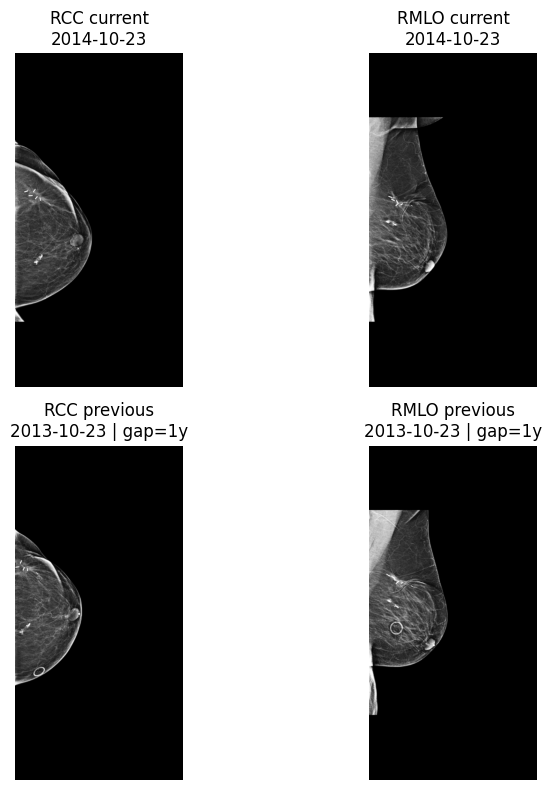

,view_code,current_date,previous_date,pred_year_1,pred_year_2,pred_year_3,pred_year_4,pred_year_5
0,RCC,2014-10-23 00:00:00,2013-10-23 00:00:00,0.0000,0.0005,0.0025,0.0176,0.0534
1,RMLO,2014-10-23 00:00:00,2013-10-23 00:00:00,0.0001,0.0007,0.0043,0.0337,0.1125


,year,mean_risk_across_4_views
0,year_1,0.0001
1,year_2,0.0006
2,year_3,0.0034
3,year_4,0.0256
4,year_5,0.0829


Ground-truth summary derived from the CSV with the same target logic as the dataset class:


,view_code,label,density,time_to_cancer_years_raw,years_last_followup,event_observed,event_time_index,risk_target_years_1_to_5,censor_bucket
0,RCC,Non-Cancer,2.0,4.0,3,1,3,"[0, 0, 0, 1, 1]",0
1,RMLO,Non-Cancer,2.0,4.0,3,1,3,"[0, 0, 0, 1, 1]",0


Patient-level ground truth (deduplicated across the four views):


,label,time_to_cancer_years_raw,years_last_followup,event_observed,risk_target_years_1_to_5,censor_bucket
0,Non-Cancer,4.0,3,1,"[0, 0, 0, 1, 1]",0


In [15]:
pair_df = select_patient_pairs(pair_index_df, PATIENT_ID, STUDY_DATE)
pair_df = attach_metadata(pair_df, metadata_df)
show_pair_images(pair_df)

pred_df = predict_for_pairs(model, pair_df, DEVICE)

prediction_cols = ['view_code', 'current_date', 'previous_date'] + [f'pred_year_{i}' for i in range(1, NUM_YEARS + 1)]
display(pred_df[prediction_cols].style.format({f'pred_year_{i}': '{:.4f}' for i in range(1, NUM_YEARS + 1)}))

patient_level_scores = pred_df[[f'pred_year_{i}' for i in range(1, NUM_YEARS + 1)]].mean(axis=0)
patient_level_df = pd.DataFrame(
    {
        'year': [f'year_{i}' for i in range(1, NUM_YEARS + 1)],
        'mean_risk_across_4_views': patient_level_scores.values,
    }
)
display(patient_level_df.style.format({'mean_risk_across_4_views': '{:.4f}'}))

print('Ground-truth summary derived from the CSV with the same target logic as the dataset class:')
display(summarize_ground_truth(pair_df))

truth_cols = ['label', 'time_to_cancer_years_raw', 'years_last_followup', 'event_observed', 'risk_target_years_1_to_5', 'censor_bucket']
unique_truth = pair_df[truth_cols].copy()
unique_truth['risk_target_years_1_to_5_str'] = unique_truth['risk_target_years_1_to_5'].apply(lambda x: str(list(x)))
unique_truth = unique_truth.drop_duplicates(subset=['label', 'time_to_cancer_years_raw', 'years_last_followup', 'event_observed', 'risk_target_years_1_to_5_str', 'censor_bucket'])
unique_truth = unique_truth.drop(columns=['risk_target_years_1_to_5_str']).reset_index(drop=True)
print('Patient-level ground truth (deduplicated across the four views):')
display(unique_truth)

if len(unique_truth) > 1:
    print('Warning: the four views do not map to a single identical ground-truth row in the CSV, so inspect the per-view table above.')

FileNotFoundError: No PNG files were found in /mnt/cv_data/users/mengxu/EMBED_Dataset_Split_Uniform_Orientation/test

## What The Model Takes As Input

The loaded model in this notebook is `RiskModelNoAlignment`, which is the no-feature-alignment longitudinal risk model used by the test pipeline. Its forward call is:

```python
model(current_image, previous_image, time_gap)
```

So yes: this model still requires a **current / prior image pair** for each prediction. In this repository, this checkpoint is not a single-exam risk model.

Each prediction unit is one adjacent longitudinal pair from the same patient, laterality, and view:

- current image: the more recent mammogram,
- previous image: the immediately preceding mammogram for the same laterality/view track,
- time gap: the year difference between the two exams, capped at 5.

For EMBED, the dataset builds these pairs independently for `LCC`, `LMLO`, `RCC`, and `RMLO` whenever that history exists. During training and testing, the code operates on these valid longitudinal pairs. If some views are missing, those missing views simply do not contribute a pair.

### Does It Make Sense To Use Longitudinal History For Risk Prediction?

It can make sense, depending on the goal of the model.

Why longitudinal history can help:

- breast cancer risk can be reflected by **change over time**, not only by appearance at one exam,
- comparing a current image with the patient's own prior image can expose subtle interval changes,
- the `time_gap` input tells the model how far apart the two exams are.

Why it is also a limitation:

- patients without prior exams cannot be scored by this exact model formulation,
- missing views or sparse history reduce the usable longitudinal information,
- a longitudinal risk model may partly capture imaging evolution that is closer to early disease change than to long-term baseline risk alone.

So the most accurate interpretation is that this is a **longitudinal mammographic risk model**. It is designed to use temporal exam history, not just a single current mammogram. If you wanted a pure single-timepoint risk model, that would need a different model design and training setup.

### Risk Score Range

The reported risk scores are in the range **0 to 1** because the model applies a sigmoid at the output layer.

- a score near `0` means low predicted risk,
- a score near `1` means high predicted risk.

In this notebook, `pred_year_1` through `pred_year_5` are probability-like model outputs for the 1-year through 5-year horizons. If you want a percentage-style interpretation, multiply the value by 100.

Examples:

- `0.12` corresponds to about `12%`,
- `0.78` corresponds to about `78%`.

Because the model is trained with cumulative year-specific targets, later-year outputs are often greater than or equal to earlier-year outputs. The extra output unit not shown in the main prediction table corresponds to the non-cancer / censoring bucket.